EE5121 - Convex Optimization  
Assignment 2 - Question 2

In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import cvxpy as cp

In [2]:
#inputs
Data = pd.read_csv('Data_Q2.csv', header=0)
X = np.asarray(Data[['x1','x2']].values.astype(float))
y = np.asarray(Data[['y']].values.astype(float))
n, d = X.shape
y = y.ravel()

In [3]:
#Helpers
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_loss_vec(w, X, y):
    z = - y * (X.dot(w))
    return np.sum(np.log1p(np.exp(z)))

def logistic_grad_vec(w, X, y):
    z = - y * (X.dot(w))
    sigma = 1.0 / (1.0 + np.exp(-z)) 
    return - X.T.dot(y * sigma)


In [4]:
#Trackers for iterates
w_iters = []
obj_iters = []
norm_iters = []

In [5]:
#Scipy callback function to store iterates
def lbfgs_callback(xk):
    w = np.asarray(xk).ravel()
    w_iters.append(w.copy())
    obj_iters.append(logistic_loss_vec(w, X, y))
    norm_iters.append(np.linalg.norm(w))

In [6]:
#Initial guess
w0 = np.zeros(d)

In [7]:
#Solution with iterates tracked, using scipy
res = minimize(fun=lambda w: logistic_loss_vec(w, X, y),
               x0=w0,
               jac=lambda w: logistic_grad_vec(w, X, y),
               method='L-BFGS-B',
               callback=lbfgs_callback,
               options={'maxiter': 1000, 'disp': False})

C:\Users\RPSARATHY\AppData\Local\Temp\ipykernel_17904\3193545790.py:2: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(fun=lambda w: logistic_loss_vec(w, X, y),


In [8]:
print("SciPy L-BFGS-B status:", res.success, res.message)
print("Number of recorded iterates:", len(w_iters))

SciPy L-BFGS-B status: True CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Number of recorded iterates: 24


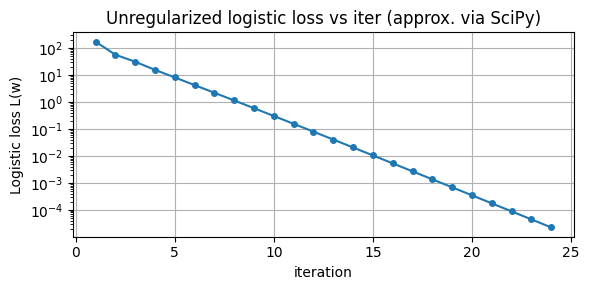

In [9]:
it = np.arange(len(obj_iters))

plt.figure(figsize=(6,3))
plt.semilogy(it + 1, obj_iters, '-o', markersize=4)
plt.xlabel('iteration')
plt.ylabel('Logistic loss L(w)')
plt.title('Unregularized logistic loss vs iter (approx. via SciPy)')
plt.grid(True)
plt.tight_layout()
plt.savefig('q2_loss_iters.png', dpi=200)

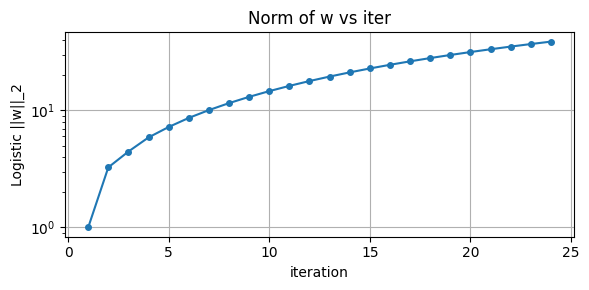

In [10]:
plt.figure(figsize=(6,3))
plt.semilogy(it + 1, norm_iters, '-o', markersize=4)
plt.xlabel('iteration')
plt.ylabel('Logistic ||w||_2')
plt.title('Norm of w vs iter')
plt.grid(True)
plt.tight_layout()
plt.savefig('q2_norm_iters.png', dpi=200)

In [11]:
lam = 1e-2
w = cp.Variable(d)
#loss
loss = cp.sum(cp.logistic(-cp.multiply(y, X @ w)))
reg = (lam / 2.0) * cp.sum_squares(w)
prob = cp.Problem(cp.Minimize(loss + reg))

# Solve with SCS or ECOS depending on availability
prob.solve()
#solver=cp.SCS, verbose=False, eps=1e-7, max_iters=10000
w_star = np.asarray(w.value).ravel()
print("CVXPY regularized solve status:", prob.status)
print("||w_star||_2 =", np.linalg.norm(w_star))


CVXPY regularized solve status: optimal
||w_star||_2 = 14.36285339108735


In [12]:
# predictions helper
def predict_sign(w, X):
    scores = X.dot(w)
    return np.where(scores >= 0, 1, -1)

# unregularized final from SciPy (w_final_unreg) and regularized CVXPY (w_star)
w_unreg = w_iters[-1]
w_reg = w_star

# compute training losses and norms
L_unreg = logistic_loss_vec(w_unreg, X, y)
L_reg = logistic_loss_vec(w_reg, X, y) + (lam/2.0) * np.sum(w_reg**2)

acc_unreg = np.mean(predict_sign(w_unreg, X) == y)
acc_reg = np.mean(predict_sign(w_reg, X) == y)

print(f"Unregularized (SciPy final): loss={L_unreg:.6g}, ||w||={np.linalg.norm(w_unreg):.6g}, train-acc={acc_unreg:.4f}")
print(f"Regularized (CVXPY):         loss+reg={L_reg:.6g}, ||w||={np.linalg.norm(w_reg):.6g}, train-acc={acc_reg:.4f}")


print("\nIterate behavior: final objective (first/last):", obj_iters[0], "->", obj_iters[-1])
print("Final iterate norm:", norm_iters[-1])


print(f"SciPy_iter_count: {len(obj_iters)}")
print(f"Unreg_final_loss: {L_unreg}")
print(f"Reg_obj: {float(prob.value)}")
print(f"||w_star||: {np.linalg.norm(w_reg)}")
print(f"train_acc_reg: {acc_reg}")


Unregularized (SciPy final): loss=2.22487e-05, ||w||=38.6779, train-acc=1.0000
Regularized (CVXPY):         loss+reg=1.36879, ||w||=14.3629, train-acc=1.0000

Iterate behavior: final objective (first/last): 175.5947978875966 -> 2.2248711011437346e-05
Final iterate norm: 38.67787032715077
SciPy_iter_count: 24
Unreg_final_loss: 2.2248711011437346e-05
Reg_obj: 1.3687893927891674
||w_star||: 14.36285339108735
train_acc_reg: 1.0
